In [297]:
import pandas as pd
from pandas.conftest import ascending

ModuleNotFoundError: No module named 'hypothesis'

In [ ]:
import numpy as np

In [ ]:
df = pd.read_csv('expense.csv')
df.head()

Convert the date column to a datetime object.

In [ ]:
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y')
df.head()


Extract the year, month, and day from the date column.

In [ ]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df.head()


Filter all transactions that occurred in 2024.


In [ ]:
mdf = df.loc[df['year'] == 2024]
mdf.head()


Filter all transactions that occurred in March of any year.

In [ ]:
mdf= df.loc[df['month']==3]
mdf.head()

Find all transactions that happened on Fridays.

In [ ]:
df['day']=df['date'].dt.day_name()
mdf = df.loc[df['day']=='Friday']
mdf.head()

Intermediate Questions

Calculate the day of the week for each transaction.

In [ ]:
df['day_of_week'] = df['date'].dt.day_of_week
df.head()

Find the total amount spent per month.

In [ ]:
df['month_names'] = df['date'].dt.month_name()
month_spent =df.groupby(df['month_names']).agg(
    spent_per_month = ('amount','sum')
).sort_values(by='spent_per_month', ascending=False)
month_spent


Find the average amount spent per category for each year.

In [ ]:
df.groupby(['category','year']).agg(
    spent_per_year = ('amount','mean')
).round(2)

Find all transactions that happened in the first quarter (Jan–Mar) of any year. doubt without variable doesnt work

In [ ]:
bdf = df.loc[df['date'].dt.quarter==1]
bdf

Calculate the monthly growth in spending compared to the previous month.

In [ ]:
month_spent =df.groupby(['year', 'month']).agg(
      amount_per_month = ('amount', 'sum')
).reset_index().sort_values(['year', 'month']).head()

month_spent['monthly_growth'] = month_spent['amount_per_month'].pct_change()

month_spent

Identify the category with the highest spending in each quarter. DOUBT###


In [ ]:
df['Quarter'] = df['date'].dt.quarter
mdf = df.groupby(['category','Quarter']).agg(
    highest_spent = ('amount', 'sum')
)
mdf.groupby(['Quarter']).agg(
    max_spent = ('highest_spent', 'max')
)


In [ ]:
df = pd.read_csv('expense_datetime.csv')
df.head()

Convert the date column to a pandas datetime object.

Extract the year, month, day, hour, minute, and second from the date column.
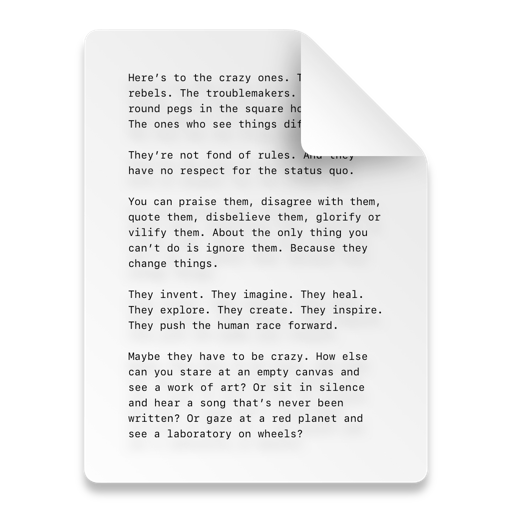

In [ ]:
df['date'] = pd.to_datetime(df['date'] , format = '%Y/%m/%d %H:%M:%S')
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['hour'] = df['date'].dt.hour
df['minute'] = df['date'].dt.minute
df['second'] = df['date'].dt.second
df.head()

Filter all transactions that occurred in 2024.

In [ ]:
fdf = df.loc[df['year']==2024]
fdf.head()


Filter all transactions that occurred in January of any year.

In [298]:
df['month_name'] = df['date'].dt.month_name()
mdf = df.loc[df['month_name'] == 'January' ]
mdf

KeyError: 'date'

Filter all transactions that occurred after 6 PM.

In [ ]:
mdf = df.loc[df['hour'] >= 18]
mdf.head()

Calculate the total spending per month and sort it chronologically

In [ ]:
mdf = df.groupby(['month','month_name']).agg(
    Spending_per_month = ('amount','sum')
)
mdf

Calculate the average spending per category per year.

In [ ]:
mdf = df.groupby(['category','year']).agg(
    average_spent = ('amount', 'mean')
).round(2).sort_values(['average_spent','year'],ascending =False)
mdf

Identify the month with the highest total spending in each year. DOUBT ####

In [ ]:
mdf = df.groupby(['year','month']).agg(
    Spending_per_month = ('amount','sum')
)
mdf.groupby(['year']).agg(
    max_spend = ('Spending_per_month', 'max')
)


Calculate the monthly growth in spending compared to the previous month.

Find the category with the highest spending in each quarter. DOUBT ###

In [ ]:
df['quarter'] = df['date'].dt.quarter
mdf= df.groupby(['category','quarter']).agg(
    Spending_per_quarter = ('amount', 'sum')
)
mdf.groupby(['category','quarter']).agg(
    max_spend = ('Spending_per_quarter', 'max')
)

In [300]:
df=pd.read_csv('fast_delivery.csv')
df.head()

,promised_delivery_time,actual_delivery_time
0,2024-07-17 08:52:01,2024-07-17 08:47:01
1,2024-05-28 13:25:29,2024-05-28 13:27:29
2,2024-09-23 13:25:12,2024-09-23 13:29:12
3,2023-11-24 16:34:56,2023-11-24 16:33:56
4,2023-11-20 05:17:39,2023-11-20 05:18:39


Convert both promised_delivery_time and actual_delivery_time to pandas datetime objects.

In [301]:
df['promised_delivery_time'] = pd.to_datetime(df['promised_delivery_time'], format='%Y-%m-%d %H:%M:%S')
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'], format='%Y-%m-%d %H:%M:%S')
df


,promised_delivery_time,actual_delivery_time
0,2024-07-17 08:52:01,2024-07-17 08:47:01
1,2024-05-28 13:25:29,2024-05-28 13:27:29
2,2024-09-23 13:25:12,2024-09-23 13:29:12
3,2023-11-24 16:34:56,2023-11-24 16:33:56
4,2023-11-20 05:17:39,2023-11-20 05:18:39
5,2023-03-18 16:49:51,2023-03-18 16:48:51
6,2023-04-16 19:01:37,2023-04-16 19:02:37
7,2023-06-27 00:38:22,2023-06-27 00:35:22
8,2024-07-18 14:52:59,2024-07-18 14:51:59
9,2024-06-10 07:32:02,2024-06-10 07:32:02



Extract date, hour, minute, and second from promised_delivery_time.

In [302]:
df['promised_date'] = df['promised_delivery_time'].dt.date
df['promised_hour'] = df['promised_delivery_time'].dt.hour
df['promised_minute'] = df['promised_delivery_time'].dt.minute
df['promised_second'] = df['promised_delivery_time'].dt.second
df

,promised_delivery_time,actual_delivery_time,promised_date,promised_hour,promised_minute,promised_second
0,2024-07-17 08:52:01,2024-07-17 08:47:01,2024-07-17,8,52,1
1,2024-05-28 13:25:29,2024-05-28 13:27:29,2024-05-28,13,25,29
2,2024-09-23 13:25:12,2024-09-23 13:29:12,2024-09-23,13,25,12
3,2023-11-24 16:34:56,2023-11-24 16:33:56,2023-11-24,16,34,56
4,2023-11-20 05:17:39,2023-11-20 05:18:39,2023-11-20,5,17,39
5,2023-03-18 16:49:51,2023-03-18 16:48:51,2023-03-18,16,49,51
6,2023-04-16 19:01:37,2023-04-16 19:02:37,2023-04-16,19,1,37
7,2023-06-27 00:38:22,2023-06-27 00:35:22,2023-06-27,0,38,22
8,2024-07-18 14:52:59,2024-07-18 14:51:59,2024-07-18,14,52,59
9,2024-06-10 07:32:02,2024-06-10 07:32:02,2024-06-10,7,32,2


Filter deliveries that occurred in 2024.

In [303]:
bdf = df.loc[df['actual_delivery_time'].dt.year ==2024]
bdf

,promised_delivery_time,actual_delivery_time,promised_date,promised_hour,promised_minute,promised_second
0,2024-07-17 08:52:01,2024-07-17 08:47:01,2024-07-17,8,52,1
1,2024-05-28 13:25:29,2024-05-28 13:27:29,2024-05-28,13,25,29
2,2024-09-23 13:25:12,2024-09-23 13:29:12,2024-09-23,13,25,12
8,2024-07-18 14:52:59,2024-07-18 14:51:59,2024-07-18,14,52,59
9,2024-06-10 07:32:02,2024-06-10 07:32:02,2024-06-10,7,32,2


Filter deliveries where the promised_delivery_time was in the morning (00:00–11:59).

In [304]:
df['promised time'] = df['promised_delivery_time'].dt.time
bdf = df.loc[(df['promised_hour'] >= 0) & (df['promised_hour'] <= 12)]
bdf

,promised_delivery_time,actual_delivery_time,promised_date,promised_hour,promised_minute,promised_second,promised time
0,2024-07-17 08:52:01,2024-07-17 08:47:01,2024-07-17,8,52,1,08:52:01
4,2023-11-20 05:17:39,2023-11-20 05:18:39,2023-11-20,5,17,39,05:17:39
7,2023-06-27 00:38:22,2023-06-27 00:35:22,2023-06-27,0,38,22,00:38:22
9,2024-06-10 07:32:02,2024-06-10 07:32:02,2024-06-10,7,32,2,07:32:02


Identify deliveries where the promised and actual times are exactly the same.

In [305]:
bdf = df.loc[df['promised_delivery_time'] == df['actual_delivery_time']]
bdf

,promised_delivery_time,actual_delivery_time,promised_date,promised_hour,promised_minute,promised_second,promised time
9,2024-06-10 07:32:02,2024-06-10 07:32:02,2024-06-10,7,32,2,07:32:02


Calculate the time difference between actual_delivery_time and promised_delivery_time for each record

In [307]:
df['Time_diff_min'] = (df['promised_delivery_time'] - df['actual_delivery_time']).dt.total_seconds()/60.00
df

,promised_delivery_time,actual_delivery_time,promised_date,promised_hour,promised_minute,promised_second,promised time,Time_diff_min
0,2024-07-17 08:52:01,2024-07-17 08:47:01,2024-07-17,8,52,1,08:52:01,5.0
1,2024-05-28 13:25:29,2024-05-28 13:27:29,2024-05-28,13,25,29,13:25:29,-2.0
2,2024-09-23 13:25:12,2024-09-23 13:29:12,2024-09-23,13,25,12,13:25:12,-4.0
3,2023-11-24 16:34:56,2023-11-24 16:33:56,2023-11-24,16,34,56,16:34:56,1.0
4,2023-11-20 05:17:39,2023-11-20 05:18:39,2023-11-20,5,17,39,05:17:39,-1.0
5,2023-03-18 16:49:51,2023-03-18 16:48:51,2023-03-18,16,49,51,16:49:51,1.0
6,2023-04-16 19:01:37,2023-04-16 19:02:37,2023-04-16,19,1,37,19:01:37,-1.0
7,2023-06-27 00:38:22,2023-06-27 00:35:22,2023-06-27,0,38,22,00:38:22,3.0
8,2024-07-18 14:52:59,2024-07-18 14:51:59,2024-07-18,14,52,59,14:52:59,1.0
9,2024-06-10 07:32:02,2024-06-10 07:32:02,2024-06-10,7,32,2,07:32:02,0.0


Find deliveries that were late (actual > promised) and early (actual < promised).

In [313]:
bdf = df.loc[df['Time_diff_min'] !=0]
bdf

,promised_delivery_time,actual_delivery_time,promised_date,promised_hour,promised_minute,promised_second,promised time,Time_diff_min
0,2024-07-17 08:52:01,2024-07-17 08:47:01,2024-07-17,8,52,1,08:52:01,5.0
1,2024-05-28 13:25:29,2024-05-28 13:27:29,2024-05-28,13,25,29,13:25:29,-2.0
2,2024-09-23 13:25:12,2024-09-23 13:29:12,2024-09-23,13,25,12,13:25:12,-4.0
3,2023-11-24 16:34:56,2023-11-24 16:33:56,2023-11-24,16,34,56,16:34:56,1.0
4,2023-11-20 05:17:39,2023-11-20 05:18:39,2023-11-20,5,17,39,05:17:39,-1.0
5,2023-03-18 16:49:51,2023-03-18 16:48:51,2023-03-18,16,49,51,16:49:51,1.0
6,2023-04-16 19:01:37,2023-04-16 19:02:37,2023-04-16,19,1,37,19:01:37,-1.0
7,2023-06-27 00:38:22,2023-06-27 00:35:22,2023-06-27,0,38,22,00:38:22,3.0
8,2024-07-18 14:52:59,2024-07-18 14:51:59,2024-07-18,14,52,59,14:52:59,1.0


Or i marked late and early deliveries

In [342]:
import numpy as np
df['delivery'] = np.where(
    df['Time_diff_min'] > 0, 'early',
    np.where(df['Time_diff_min'] < 0, 'late', 'on-time')
)
df

,promised_delivery_time,actual_delivery_time,promised_date,promised_hour,promised_minute,promised_second,promised time,Time_diff_min,delivery
0,2024-07-17 08:52:01,2024-07-17 08:47:01,2024-07-17,8,52,1,08:52:01,5.0,early
1,2024-05-28 13:25:29,2024-05-28 13:27:29,2024-05-28,13,25,29,13:25:29,-2.0,late
2,2024-09-23 13:25:12,2024-09-23 13:29:12,2024-09-23,13,25,12,13:25:12,-4.0,late
3,2023-11-24 16:34:56,2023-11-24 16:33:56,2023-11-24,16,34,56,16:34:56,1.0,early
4,2023-11-20 05:17:39,2023-11-20 05:18:39,2023-11-20,5,17,39,05:17:39,-1.0,late
5,2023-03-18 16:49:51,2023-03-18 16:48:51,2023-03-18,16,49,51,16:49:51,1.0,early
6,2023-04-16 19:01:37,2023-04-16 19:02:37,2023-04-16,19,1,37,19:01:37,-1.0,late
7,2023-06-27 00:38:22,2023-06-27 00:35:22,2023-06-27,0,38,22,00:38:22,3.0,early
8,2024-07-18 14:52:59,2024-07-18 14:51:59,2024-07-18,14,52,59,14:52:59,1.0,early
9,2024-06-10 07:32:02,2024-06-10 07:32:02,2024-06-10,7,32,2,07:32:02,0.0,on-time


Calculate the average delay/early time across all deliveries.

In [319]:
bdf = df.groupby(['promised_delivery_time','actual_delivery_time','Time_diff_min']).agg(
    average_delay = ('Time_diff_min', 'mean')
)
bdf

,,,average_delay
promised_delivery_time,actual_delivery_time,Time_diff_min,
2023-03-18 16:49:51,2023-03-18 16:48:51,1.0,1.0
2023-04-16 19:01:37,2023-04-16 19:02:37,-1.0,-1.0
2023-06-27 00:38:22,2023-06-27 00:35:22,3.0,3.0
2023-11-20 05:17:39,2023-11-20 05:18:39,-1.0,-1.0
2023-11-24 16:34:56,2023-11-24 16:33:56,1.0,1.0
2024-05-28 13:25:29,2024-05-28 13:27:29,-2.0,-2.0
2024-06-10 07:32:02,2024-06-10 07:32:02,0.0,0.0
2024-07-17 08:52:01,2024-07-17 08:47:01,5.0,5.0
2024-07-18 14:52:59,2024-07-18 14:51:59,1.0,1.0



Find the maximum delay and the corresponding delivery date.

In [320]:
bdf = df.loc[df['Time_diff_min'].idxmax()]
bdf

promised_delivery_time    2024-07-17 08:52:01
actual_delivery_time      2024-07-17 08:47:01
promised_date                      2024-07-17
promised_hour                               8
promised_minute                            52
promised_second                             1
promised time                        08:52:01
Time_diff_min                             5.0
delivery                                early
Name: 0, dtype: object

Find the minimum delay and the corresponding delivery date. DOUBT###

In [333]:

gdf = df.loc[df['Time_diff_min'].idxmin()]
gdf

promised_delivery_time    2024-09-23 13:25:12
actual_delivery_time      2024-09-23 13:29:12
promised_date                      2024-09-23
promised_hour                              13
promised_minute                            25
promised_second                            12
promised time                        13:25:12
Time_diff_min                            -4.0
delivery                                 late
Name: 2, dtype: object

Count how many deliveries were on time (difference = 0).

In [346]:
bdf = df.loc[df['Time_diff_min'] == 0]
bdf

,promised_delivery_time,actual_delivery_time,promised_date,promised_hour,promised_minute,promised_second,promised time,Time_diff_min,delivery
9,2024-06-10 07:32:02,2024-06-10 07:32:02,2024-06-10,7,32,2,07:32:02,0.0,on-time


Find the total number of deliveries that were late by more than 5 minutes.

In [344]:
bdf = df.loc[df['Time_diff_min'] >= 5.0]
bdf

,promised_delivery_time,actual_delivery_time,promised_date,promised_hour,promised_minute,promised_second,promised time,Time_diff_min,delivery
0,2024-07-17 08:52:01,2024-07-17 08:47:01,2024-07-17,8,52,1,08:52:01,5.0,early


In [347]:
df=pd.read_csv('timestamp.csv')
df

,order_id,order_time,delivery_time
0,101,1732003200,1732005000
1,102,1732100000,1732103600
2,103,1732150000,1732150900
3,104,1732200000,1732207200
4,105,1732250000,1732250300


Convert order_time and delivery_time from Unix timestamps to human-readable datetime.

In [348]:
df['order_time'] = pd.to_datetime(df['order_time'], unit='s')
df['delivery_time'] = pd.to_datetime(df['delivery_time'], unit='s')
df.head()

,order_id,order_time,delivery_time
0,101,2024-11-19 08:00:00,2024-11-19 08:30:00
1,102,2024-11-20 10:53:20,2024-11-20 11:53:20
2,103,2024-11-21 00:46:40,2024-11-21 01:01:40
3,104,2024-11-21 14:40:00,2024-11-21 16:40:00
4,105,2024-11-22 04:33:20,2024-11-22 04:38:20


Extract year, month, day, hour, minute, and second from order_time.

In [350]:
df['year'] = df['order_time'].dt.year
df['month'] = df['order_time'].dt.month
df['day'] = df['order_time'].dt.day
df['hour'] = df['order_time'].dt.hour
df['minute'] = df['order_time'].dt.minute
df['second'] = df['order_time'].dt.second
df.head()

,order_id,order_time,delivery_time,year,month,day,hour,minute,second
0,101,2024-11-19 08:00:00,2024-11-19 08:30:00,2024,11,19,8,0,0
1,102,2024-11-20 10:53:20,2024-11-20 11:53:20,2024,11,20,10,53,20
2,103,2024-11-21 00:46:40,2024-11-21 01:01:40,2024,11,21,0,46,40
3,104,2024-11-21 14:40:00,2024-11-21 16:40:00,2024,11,21,14,40,0
4,105,2024-11-22 04:33:20,2024-11-22 04:38:20,2024,11,22,4,33,20


Filter orders that occurred in a specific year (e.g., 2025).

In [351]:
bdf= df.loc[df['year'] == 2025]
bdf

,order_id,order_time,delivery_time,year,month,day,hour,minute,second


Filter orders that occurred in a specific month.

Identify orders where the delivery_time is exactly the same as order_time.

In [353]:
bdf = df.loc[df['delivery_time'] == df['order_time']]
bdf

,order_id,order_time,delivery_time,year,month,day,hour,minute,second
